# Lea Rado, Final Assignment, Fairness Metrics Comparison
Link to Dataset: https://www.kaggle.com/datasets/mysarahmadbhat/lung-cancer

Author: Lea Rado (s1068713)

In [13]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, auc
)

In [14]:
# load dataset
df = pd.read_csv('survey lung cancer.csv')

In [15]:
# Exploratory Analysis
print("Check for Missing Values")
print(df.isnull().sum())
print("\nClass Distribution")
print(df['LUNG_CANCER'].value_counts())
print("\nGender Distribution")
print(df['GENDER'].value_counts())
print("\nCancer by Gender")
print(pd.crosstab(df['GENDER'], df['LUNG_CANCER'], margins=True))

Check for Missing Values
GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

Class Distribution
LUNG_CANCER
YES    270
NO      39
Name: count, dtype: int64

Gender Distribution
GENDER
M    162
F    147
Name: count, dtype: int64

Cancer by Gender
LUNG_CANCER  NO  YES  All
GENDER                   
F            22  125  147
M            17  145  162
All          39  270  309


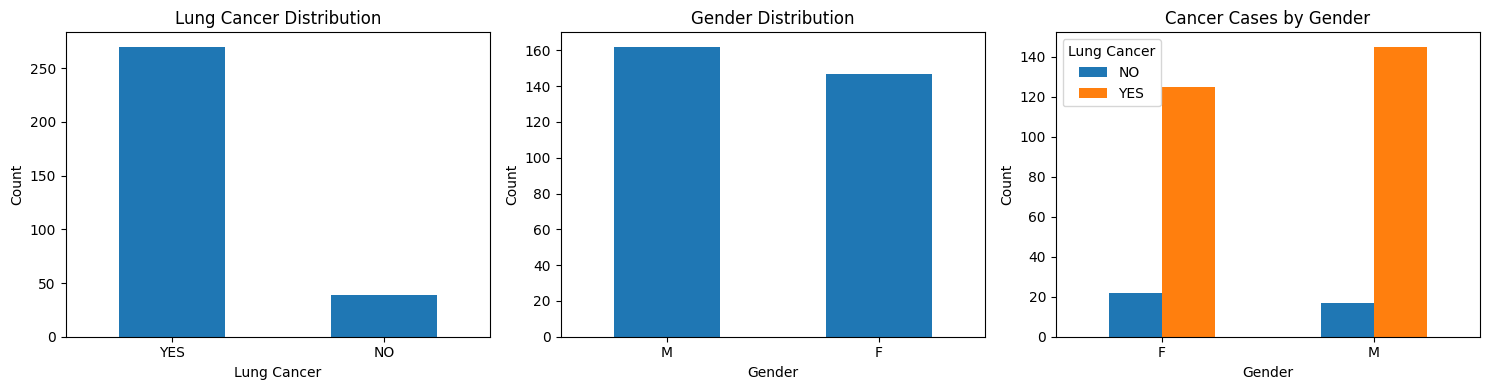

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Cancer prevalence
df['LUNG_CANCER'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Lung Cancer Distribution')
axes[0].set_xlabel('Lung Cancer'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Gender distribution
df['GENDER'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Gender Distribution')
axes[1].set_xlabel('Gender'); axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

# Cancer by gender
ct = pd.crosstab(df['GENDER'], df['LUNG_CANCER'])
ct.plot(kind='bar', ax=axes[2])
axes[2].set_title('Cancer Cases by Gender')
axes[2].set_xlabel('Gender'); axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Lung Cancer')

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

   No Cancer       0.70      0.58      0.64        12
      Cancer       0.94      0.96      0.95        81

    accuracy                           0.91        93
   macro avg       0.82      0.77      0.79        93
weighted avg       0.91      0.91      0.91        93



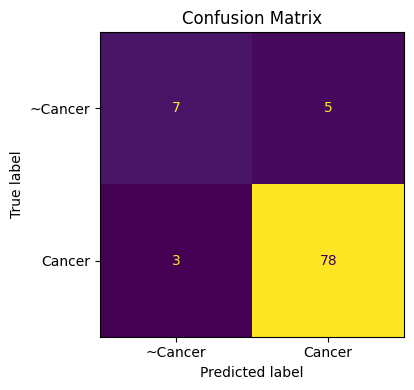

In [17]:
# Data Preprocessing
# make copy so that we are not changing the original dataset
df_model = df.copy()

# Encode target: YES=1, NO=0
df_model['LUNG_CANCER'] = (df_model['LUNG_CANCER'] == 'YES').astype(int)
# Encode Gender: M=1, F=0
df_model['GENDER_ENC'] = (df_model['GENDER'] == 'M').astype(int)

X = df_model.drop(['LUNG_CANCER', 'GENDER'],axis=1)
y = df_model['LUNG_CANCER']
gender_col = df_model['GENDER']  # keep original labels for grouping

X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
    X, y, gender_col, test_size=0.3, random_state=42, stratify=y
)

# Training the Classifier
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

# Classification Report
print(classification_report(y_test, y_pred, target_names=['No Cancer', 'Cancer']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['~Cancer', 'Cancer'],
    colorbar=False, ax=ax
)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [18]:
def compute_group_metrics(y_true, y_pred, group_series, groups=('M', 'F')):
    """
    function computes fairness metrics separately for each demographic group
    (Male and Female) and then returns a DataFrame.
    Returns DataFrame indexed per group:
      - TP, FP, TN, FN
      - TPR (Sensitivity / Recall)
      - FPR (1 - Specificity)
      - PPV (Precision)
      - Support (total positives in true labels)
    """
    results = []
    for g in groups:
        # filter data and extract only rows belonging to F/M respectively
        mask = group_series == g
        yt = np.array(y_true)[mask]
        yp = np.array(y_pred)[mask]

        # building the confusion matrix
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()

        # calculation of fairness metrics
        tpr = tp / (tp + fn)  # Sensitivity
        fpr = fp / (fp + tn)  # 1 - Specificity
        ppv = tp / (tp + fp)  # Precision

        # store results as dictionary and appends it to results list
        results.append({
            'Group': g, 'N': mask.sum(),
            'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
            'TPR': round(tpr, 4),
            'FPR': round(fpr, 4),
            'PPV': round(ppv, 4),
            'Support_Pos': int(yt.sum())   # total num of actual pos cases
        })
    return pd.DataFrame(results).set_index('Group')

metrics_df = compute_group_metrics(y_test, y_pred, g_test)
print(metrics_df)

        N  TP  FP  TN  FN     TPR     FPR     PPV  Support_Pos
Group                                                         
M      53  47   3   2   1  0.9792  0.6000  0.9400           48
F      40  31   2   5   2  0.9394  0.2857  0.9394           33


## Fairness Metric 1: Equalized Odds

Equalized Odds requires that both the True Positive Rate (TPR) and the False Positive Rate (FPR) are equal across demographic groups.

- A TPR disparity means one group is less likely to be correctly identified as having cancer.
- An FPR disparity means one group is more likely to receive a false cancer diagnosis.

In [19]:
# from group metrics calculated using helper function, get TPR/FPR for M/F
tpr_M = metrics_df.loc['M', 'TPR']
tpr_F = metrics_df.loc['F', 'TPR']
fpr_M = metrics_df.loc['M', 'FPR']
fpr_F = metrics_df.loc['F', 'FPR']

# calculate absolute difference between demographic groups
tpr_diff = abs(tpr_M - tpr_F)
fpr_diff = abs(fpr_M - fpr_F)

# print results nicely
print("Equalized Odds (TPR / FPR)")
print(f"TPR - Male: {tpr_M:.4f} | Female: {tpr_F:.4f} | |delta|: {tpr_diff:.4f}")
print(f"FPR - Male: {fpr_M:.4f} | Female: {fpr_F:.4f} | |delta|: {fpr_diff:.4f}")
print()

# fairness threshold
THRESHOLD = 0.05
# check whether parity is satisfied given fairness threshold
tpr_fair = tpr_diff <= THRESHOLD
fpr_fair = fpr_diff <= THRESHOLD

# print results nicely
print(f"TPR parity satisfied (|delta| <= {THRESHOLD})? {'YES' if tpr_fair else 'NO'}")
print(f"FPR parity satisfied (|delta| <= {THRESHOLD})? {'YES' if fpr_fair else 'NO'}")

Equalized Odds (TPR / FPR)
TPR - Male: 0.9792 | Female: 0.9394 | |delta|: 0.0398
FPR - Male: 0.6000 | Female: 0.2857 | |delta|: 0.3143

TPR parity satisfied (|delta| <= 0.05)? YES
FPR parity satisfied (|delta| <= 0.05)? NO


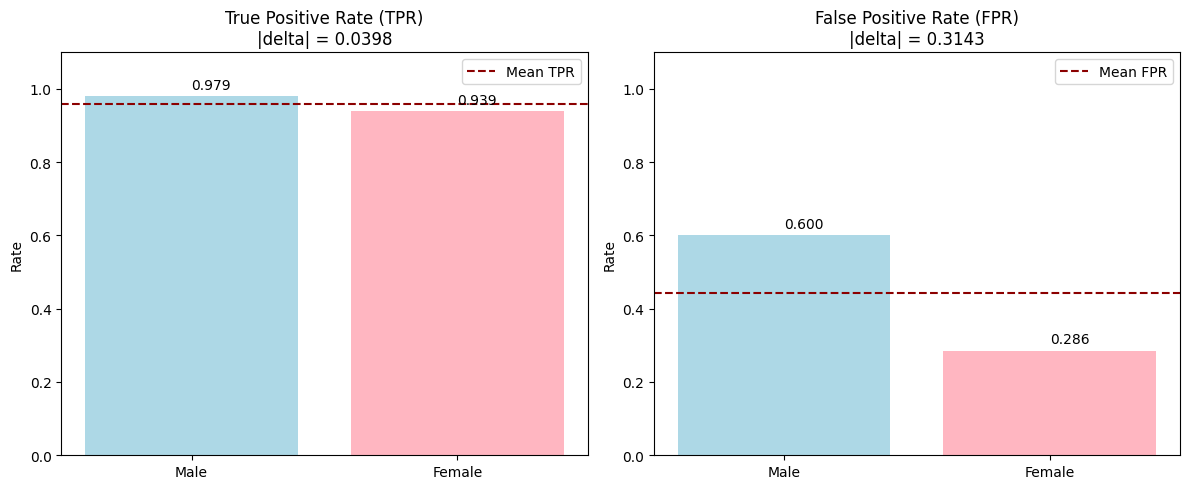

In [20]:
# plot the comparison for TPR and FPR as bar graphs
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = {'M': '#ADD8E6', 'F': '#FFB6C1'}
groups = ['M', 'F']
labels = ['Male', 'Female']

# TPR comparison
tpr_vals = [metrics_df.loc[g, 'TPR'] for g in groups]
bars = axes[0].bar(labels, tpr_vals, color=[colors[g] for g in groups])
# plot the difference between two values on y-axis (absolute delta)
axes[0].axhline(y=np.mean(tpr_vals), color='#8B0000',
                linestyle='--', label='Mean TPR')
axes[0].set_ylim(0, 1.1)
axes[0].set_title(f'True Positive Rate (TPR)\n|delta| = {tpr_diff:.4f}')
axes[0].set_ylabel('Rate')
for bar, val in zip(bars, tpr_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}')
axes[0].legend()

# FPR comparison
fpr_vals = [metrics_df.loc[g, 'FPR'] for g in groups]
bars2 = axes[1].bar(labels, fpr_vals, color=[colors[g] for g in groups])
# plot the difference between two values on y-axis (absolute delta)
axes[1].axhline(y=np.mean(fpr_vals), color='#8B0000',
                linestyle='--', label='Mean FPR')
axes[1].set_ylim(0, 1.1)
axes[1].set_title(f'False Positive Rate (FPR)\n|delta| = {fpr_diff:.4f}')
axes[1].set_ylabel('Rate')
for bar, val in zip(bars2, fpr_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## Fairness Metric 2: PPV (Positive Predictive Value) Parity

PPV Parity requires that the Positive Predictive Value is equal across groups.

- PPV = TP / (TP + FP)  
- A PPV disparity means the model's positive predictions are more trustworthy for one group than another.

In [21]:
# from group metrics calculated using helper function, get PPV value for M/F
ppv_M = metrics_df.loc['M', 'PPV']
ppv_F = metrics_df.loc['F', 'PPV']

# calculate absolute difference between two demographic groups
ppv_diff = abs(ppv_M - ppv_F)
print("PPV Parity")
print(f"Male: {ppv_M:.4f} | Female: {ppv_F:.4f} | |delta|: {ppv_diff:.4f}")

# using threshold previously defined, check whether parity is satisfied.
ppv_fair = ppv_diff <= THRESHOLD
print(f"PPV parity satisfied (|delta| <= {THRESHOLD})? {'YES' if ppv_fair else 'NO'}")

PPV Parity
Male: 0.9400 | Female: 0.9394 | |delta|: 0.0006
PPV parity satisfied (|delta| <= 0.05)? YES


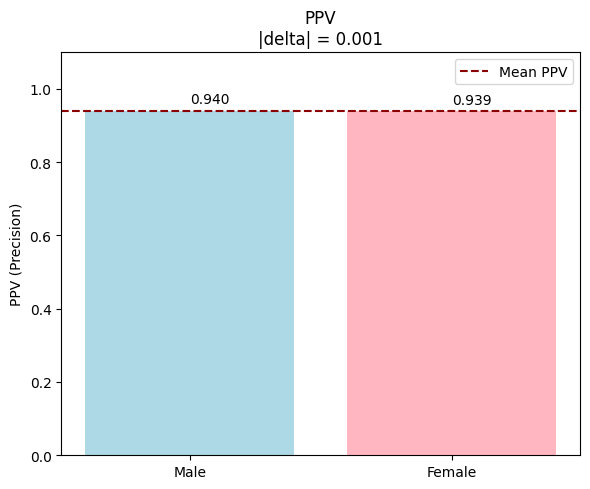

In [22]:
# plot using bar graphs
fig, ax = plt.subplots(figsize=(6, 5))

ppv_vals = [metrics_df.loc[g, 'PPV'] for g in groups]
bars = ax.bar(labels, ppv_vals, color=[colors[g] for g in groups])
# plot the difference between two values on y-axis (absolute delta)
ax.axhline(y=np.mean(ppv_vals), color='#8B0000',
           linestyle='--', label='Mean PPV')
ax.set_ylim(0, 1.1)
ax.set_title(f'PPV\n|delta| = {ppv_diff:.3f}')
ax.set_ylabel('PPV (Precision)')
for bar, val in zip(bars, ppv_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}')
ax.legend()
plt.tight_layout()
plt.show()

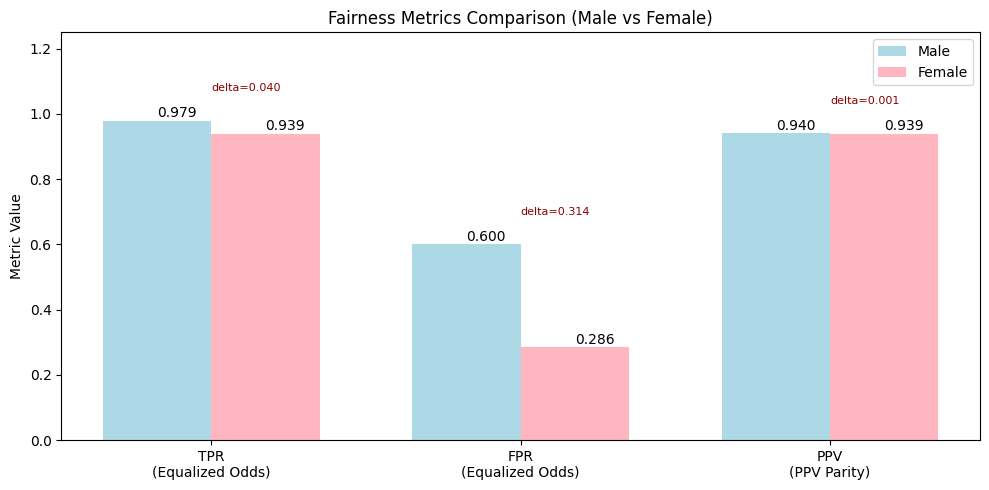

In [23]:
# side-by-side comparison of both explanations
fig, ax = plt.subplots(figsize=(10, 5))

metric_names = ['TPR', 'FPR', 'PPV']
male_vals   = [metrics_df.loc['M', m] for m in metric_names]
female_vals = [metrics_df.loc['F', m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

b1 = ax.bar(x - width/2, male_vals,   width, label='Male',   color='#ADD8E6')
b2 = ax.bar(x + width/2, female_vals, width, label='Female', color='#FFB6C1')

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}')
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}')

# annotate disparity
diffs = [abs(m - f) for m, f in zip(male_vals, female_vals)]
for i, (diff, m, f) in enumerate(zip(diffs, male_vals, female_vals)):
    y_max = max(m, f) + 0.07
    ax.annotate('', xy=(i + width/2, y_max), xytext=(i - width/2, y_max))
    ax.text(i, y_max + 0.02, f'delta={diff:.3f}', fontsize=8, color='#8B0000')

ax.set_xticks(x)
ax.set_xticklabels(['TPR\n(Equalized Odds)', 'FPR\n(Equalized Odds)', 'PPV\n(PPV Parity)'])
ax.set_ylim(0, 1.25)
ax.set_ylabel('Metric Value')
ax.set_title('Fairness Metrics Comparison (Male vs Female)')
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()